# Porównawcza analiza skuteczności algorytmów uczenia maszynowego w zadaniu klasyfikacji binarnej zadowolenia pasażerów linii lotniczych na podstawie zbioru danych Airline Passenger Satisfaction.

**Dominika Boguszewska, Natalia Pieczko** — Zaawansowane Uczenie Maszynowe, czerwiec 2026

> **Tryb fast** — ten notebook jest skróconą wersją `main.ipynb`. Zbiór treningowy jest ograniczony do 10 000 próbek, a CV do 3 foldów, co pozwala na szybkie sprawdzenie wyników kosztem precyzji. Wyniki mogą nieznacznie odbiegać od pełnej analizy.

## Konfiguracja środowiska (Google Colab)

Poniższe komórki konfigurują środowisko. Uruchom je kolejno przed właściwą analizą. Lokalnie (poza Colabem) zostaną automatycznie pominięte.

**Wymagane sekrety Colab** (ikona 🔑 w lewym panelu → *Add new secret*):
| Nazwa | Wartość |
|---|---|
| `KAGGLE_USERNAME` | Twoja nazwa użytkownika Kaggle |
| `KAGGLE_KEY` | Klucz API z [kaggle.com/settings](https://www.kaggle.com/settings) → *API* → *Create New Token* |

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_path = "/content/Airline_Passenger_Satisfaction_Classification"
    if not os.path.exists(repo_path):
        os.system(
            "git clone https://github.com/nataliap203/Airline_Passenger_Satisfaction_Classification.git "
            + repo_path
        )
    os.chdir(repo_path + "/notebooks")
    print("Katalog roboczy:", os.getcwd())

Katalog roboczy: /content/Airline_Passenger_Satisfaction_Classification/notebooks


In [2]:
if IN_COLAB:
    import subprocess, sys
    # numpy, scikit-learn, pandas, matplotlib, xgboost są pre-instalowane w Colab
    # instalujemy tylko pakiety których Colab nie zawiera
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "tabpfn>=8.0.3",
        "kaggle",
    ])
    print("Zależności gotowe.")

Zależności gotowe.


In [3]:
if IN_COLAB:
    import json
    from pathlib import Path
    from google.colab import userdata

    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(exist_ok=True)
    kaggle_path = kaggle_dir / "kaggle.json"

    if not kaggle_path.exists():
        with open(kaggle_path, "w") as f:
            json.dump({
                "username": userdata.get("KAGGLE_USERNAME"),
                "key": userdata.get("KAGGLE_KEY"),
            }, f)
        kaggle_path.chmod(0o600)
        print("Dane uwierzytelniające Kaggle skonfigurowane.")
    else:
        print("kaggle.json już istnieje.")

Dane uwierzytelniające Kaggle skonfigurowane.


## 1. Pobranie danych i import bibliotek

In [4]:
import kaggle
from pathlib import Path

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    "teejmahal20/airline-passenger-satisfaction",
    path=DATA_DIR,
    unzip=True,
)

print("Pobrane pliki:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name}")

Dataset URL: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
Pobrane pliki:
  test.csv
  train.csv


In [5]:
import os
import sys
import pandas as pd
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning:pkg_resources"

sys.path.append("..")

from sklearn.feature_selection import f_classif, mutual_info_classif

from src.preprocessing import (
    load_data,
    analyze_missing_values,
    clean_data,
    build_preprocessor,
    plot_correlation_matrix,
    plot_target_correlation,
    engineer_features,
    split_X_y,
)
from src.evaluation import evaluate, cross_validate_model, plot_pr_curve, plot_roc_curve, plot_model_metric_comparison, plot_pr_curves, plot_roc_curves
from src.models.xgboost_model import tune_hyperparameters
from src.models.logistic_regression import tune_hyperparameters as tune_hyperparameters_lr
from src.models.random_forest import tune_hyperparameters as tune_hyperparameters_rf
from src.scripts.run_selectkbest_experiment import (
    run_selectkbest_experiment,
    get_feature_scores,
    plot_k_vs_metrics,
    plot_feature_scores,
    plot_rank_comparison,
)
from src.scripts.run_rfe_experiment import (
    run_rfe_experiment,
    get_feature_rankings,
    plot_n_features_vs_metrics,
    plot_feature_rankings,
    plot_feature_rankings_comparison,
)

## 2. Przygotowanie danych

### 2.1 Ładowanie danych i analiza brakujących wartości

In [6]:
train, test = load_data()

print("=== Train ===")
print(train.shape)
train.head()

=== Train ===
(103904, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [7]:
print("=== Braki w train ===")
analyze_missing_values(train)

print("\n=== Braki w test ===")
analyze_missing_values(test)

=== Braki w train ===
                          count  percent
Arrival Delay in Minutes    310      0.3

=== Braki w test ===
                          count  percent
Arrival Delay in Minutes     83     0.32


### 2.2 Czyszczenie danych

Braki wykryto wyłącznie w `Arrival Delay in Minutes` (~0,3% obserwacji). Zastosowano usunięcie wierszy z brakującymi wartościami.

In [8]:
train_clean = clean_data(train)
test_clean = clean_data(test)

print("Train po czyszczeniu:", train_clean.shape)
print("Test po czyszczeniu: ", test_clean.shape)

Train po czyszczeniu: (103594, 23)
Test po czyszczeniu:  (25893, 23)


### 2.3 Analiza korelacji

Macierz korelacji identyfikuje zależności między cechami numerycznymi. Analiza korelacji z zmienną docelową wskazuje najsilniejsze predykatory satysfakcji — wyniki stanowią podstawę inżynierii cech.

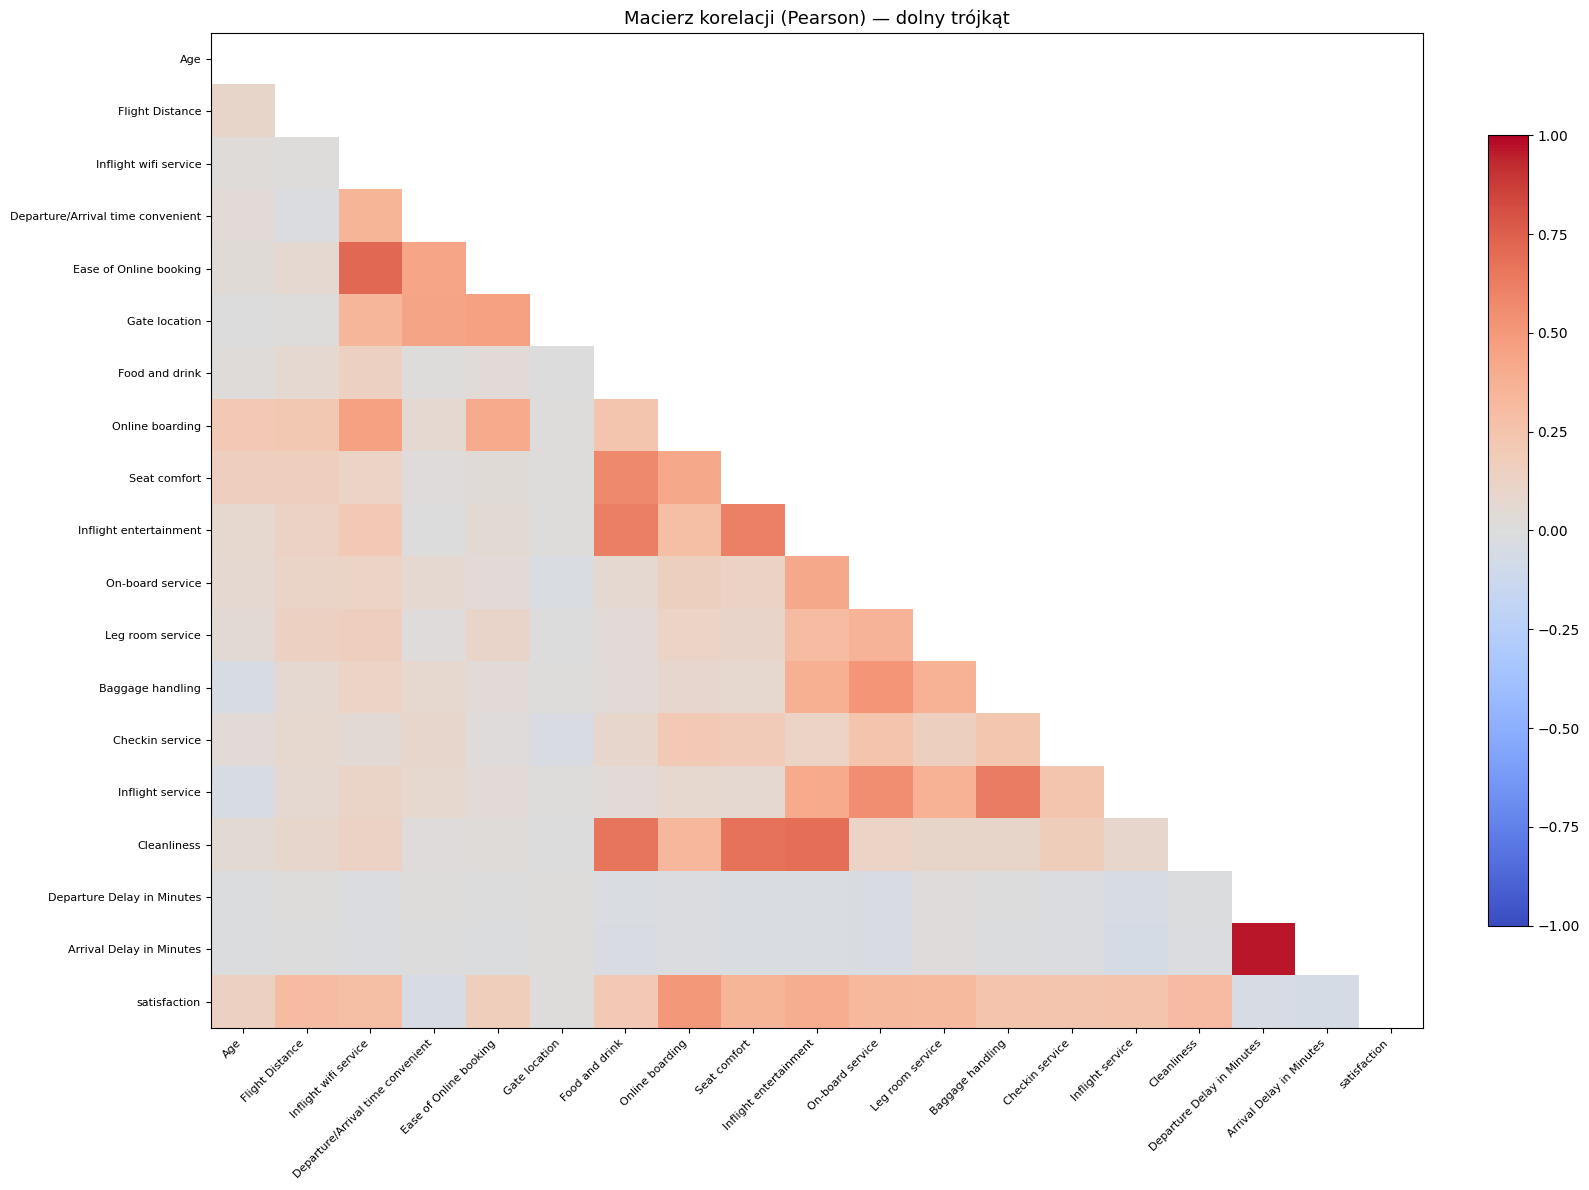

In [9]:
plot_correlation_matrix(train_clean)

Macierz korelacji wskazuje, że większość ocen jakości usług pokładowych i lotniskowych jest dodatnio skorelowana ze sobą. Najsilniejsze zależności występują między ocenami dotyczącymi komfortu podróży, takimi jak `Seat comfort`, `Inflight entertainment`, `Food and drink`, `Cleanliness` oraz obsługi, takimi jak `Inflight service`, `Baggage handling` i `On-board service`, co sugeruje, że pasażerowie wysoko oceniający jeden aspekt podróży zwykle wysoko oceniają również pozostałe.

Dla zmiennej docelowej `satisfaction` widoczne są głównie umiarkowane dodatnie korelacje z cechami związanymi z jakością usług. Najsilniej z satysfakcją powiązane są:
- `Online boarding`,
- `Inflight entertainment`,
- `Seat comfort`,
- `On-board service`,
- `Leg room service`,
- `Cleanliness`,
- `Fligth distance`.

Z kolei `Departure Delay in Minutes` i `Arrival Delay in Minutes` wykazują silną dodatnią korelację między sobą, co jest naturalne – opóźniony odlot często skutkuje opóźnionym przylotem. Jednocześnie ich korelacja z `satisfaction` jest słaba i ujemna, co sugeruje, że większe opóźnienia nieznacznie obniżają poziom satysfakcji pasażerów.

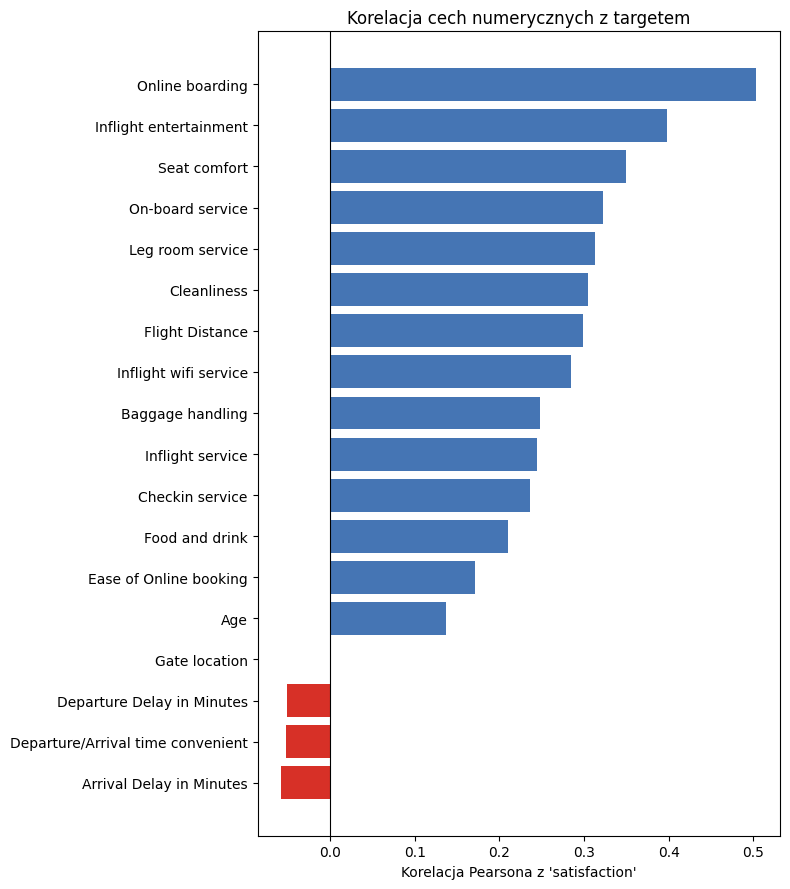

In [10]:
plot_target_correlation(train_clean)

Najsilniejszą dodatnią korelację z `satisfaction` wykazuje `Online boarding` (ok. 0.50), co sugeruje, że sprawny proces wejścia na pokład ma największy związek z zadowoleniem pasażerów. Wysokie dodatnie korelacje obserwowane są również dla `Inflight entertainment`, `Seat comfort`, `On-board service`, `Leg room service`, `Cleanliness`, `Flight Distance` oraz `Inflight wifi service`, co wskazuje, że jakość usług podczas lotu istotnie wpływa na poziom satysfakcji.

Z kolei `Departure Delay in Minutes` oraz `Arrival Delay in Minutes` są ujemnie skorelowane z `satisfaction`, co oznacza, że większe opóźnienia wiążą się z niższym poziomem zadowolenia pasażerów.

Najsłabszą zależność z targetem wykazuje `Gate location`, której korelacja jest bliska zeru, co sugeruje niewielki wpływ tej cechy na satysfakcję klientów.

### 2.4 Inżynieria cech

Na podstawie analizy danych stworzono dwie nowe cechy agregujące:
- **`total_delay`** — suma opóźnienia przylotu i wylotu (łączne doświadczenie opóźnienia)
- **`avg_service_score`** — średnia ocen 13 usług pokładowych (okazuje się najsilniejszym predyktorem)

In [11]:
train_feat = engineer_features(train_clean)
test_feat = engineer_features(test_clean)

print("Nowe kolumny:", [c for c in train_feat.columns if c not in train_clean.columns])
train_feat[["Departure Delay in Minutes", "Arrival Delay in Minutes", "total_delay", "avg_service_score"]].describe()

Nowe kolumny: ['total_delay', 'avg_service_score']


,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,avg_service_score
count,103594.000000,103594.000000,103594.000000,103594.000000
mean,14.747939,15.178678,29.926617,3.261133
std,38.116737,38.698682,76.149672,0.687609
min,0.000000,0.000000,0.000000,0.846154
25%,0.000000,0.000000,0.000000,2.769231
50%,0.000000,0.000000,2.000000,3.307692
75%,12.000000,13.000000,24.000000,3.769231
max,1592.000000,1584.000000,3176.000000,5.000000


### 2.5 Podział danych i preprocessing

Dane podzielono zgodnie z oryginalnym podziałem Kaggle: ~104 000 próbek treningowych, ~26 000 testowych. Pipeline preprocessingu (fitowany wyłącznie na zbiorze treningowym) obejmuje standaryzację cech numerycznych i one-hot encoding zmiennych kategorycznych. Łącznie uzyskano 29 cech po kodowaniu.

> **Tryb fast:** zbiór treningowy zostaje dodatkowo zredukowany do 10 000 losowych próbek (stratyfikacja), a CV ograniczone do 3 foldów — wyłącznie w celu skrócenia czasu obliczeń.

In [12]:
X_train, y_train = split_X_y(train_feat)
X_test, y_test = split_X_y(test_feat)

preprocessor = build_preprocessor(X_train)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Rozkład klas y_train:\n", y_train.value_counts())

X_train shape: (103594, 24)
X_test shape:  (25893, 24)
Rozkład klas y_train:
 satisfaction
0    58697
1    44897
Name: count, dtype: int64


In [13]:
# Fast mode: ograniczamy zbiór treningowy do 10 000 próbek
from sklearn.model_selection import train_test_split as _tts
X_train, _, y_train, _ = _tts(
    X_train, y_train, train_size=10_000, stratify=y_train, random_state=42
)
preprocessor = build_preprocessor(X_train)
print(f"Fast mode — X_train zredukowany do {X_train.shape}")

Fast mode — X_train zredukowany do (10000, 24)


## 3. Eksperyment 1 — Porównanie modeli klasycznych i zespołowych

**Pytanie badawcze:** Jak duży przyrost jakości predykcji oferują modele zespołowe w porównaniu do regresji logistycznej?

**Hipoteza:** XGBoost, dzięki technice gradient boosting, osiągnie najwyższe wyniki na pełnym zbiorze danych.

Każdy model poddano strojeniu hiperparametrów metodą GridSearchCV (3-krotna CV w trybie fast, kryterium: F1). Ocena końcowa na wydzielonym zbiorze testowym, uzupełniona krzywą Precision-Recall i krzywą ROC, pozwoliła na kompleksowe porównanie modeli.

### 3.1 Regresja logistyczna (baseline)

In [14]:
search = tune_hyperparameters_lr(preprocessor, X_train, y_train, cv=3)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Najlepsze parametry:
  model__C: 1.0
  model__l1_ratio: 0.0

Najlepsze F1 (CV): 0.8554


In [15]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train, cv=3)

print("Walidacja krzyżowa najlepszego modelu (3-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Walidacja krzyżowa najlepszego modelu (3-fold):
 accuracy       f1  roc_auc
 0.870126 0.847696 0.924622
 0.882388 0.861288 0.934417
 0.879688 0.860133 0.927344

Średnie:
accuracy    0.8774
f1          0.8564
roc_auc     0.9288

Odchylenia standardowe:
accuracy    0.0064
f1          0.0075
roc_auc     0.0051


In [16]:
best_model_lr = search.best_estimator_
metrics_lr = evaluate(best_model_lr, X_test, y_test)

accuracy    0.8721
f1          0.8514
roc_auc     0.9254

              precision    recall  f1-score   support

dissatisfied       0.87      0.90      0.89     14528
   satisfied       0.87      0.84      0.85     11365

    accuracy                           0.87     25893
   macro avg       0.87      0.87      0.87     25893
weighted avg       0.87      0.87      0.87     25893



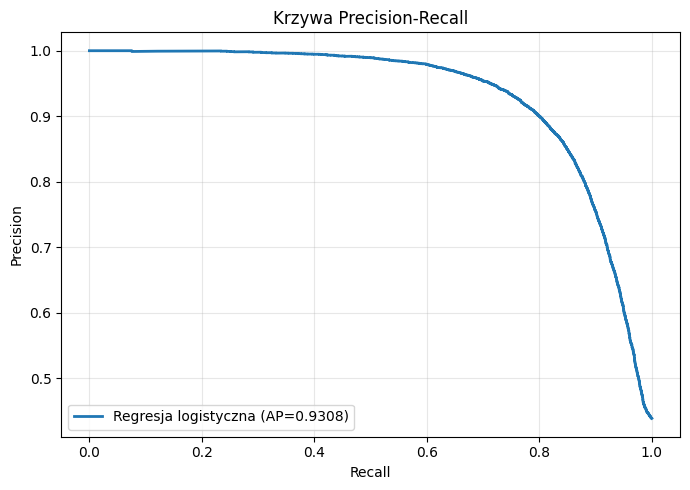

In [17]:
plot_pr_curve(best_model_lr, X_test, y_test, label="Regresja logistyczna")

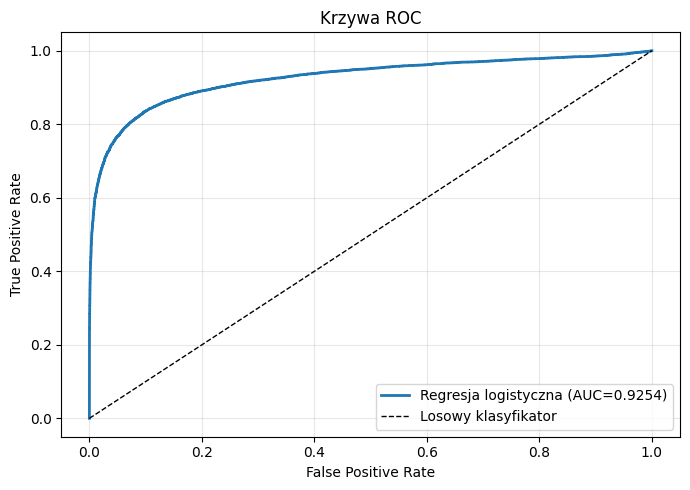

In [18]:
plot_roc_curve(best_model_lr, X_test, y_test, label="Regresja logistyczna")

### 3.2 Las losowy

In [19]:
search = tune_hyperparameters_rf(preprocessor, X_train, y_train, cv=3)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Najlepsze parametry:
  model__max_depth: None
  model__min_samples_split: 2
  model__n_estimators: 500

Najlepsze F1 (CV): 0.9393


In [20]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train, cv=3)

print("Walidacja krzyżowa najlepszego modelu (3-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (3-fold):
 accuracy       f1  roc_auc
 0.943611 0.934266 0.987044
 0.948095 0.939063 0.988716
 0.948395 0.940070 0.988709

Średnie:
accuracy    0.9467
f1          0.9378
roc_auc     0.9882

Odchylenia standardowe:
accuracy    0.0027
f1          0.0031
roc_auc     0.0010


In [21]:
best_model_rf = search.best_estimator_
metrics_rf = evaluate(best_model_rf, X_test, y_test)

accuracy    0.9508
f1          0.9435
roc_auc     0.9895

              precision    recall  f1-score   support

dissatisfied       0.95      0.96      0.96     14528
   satisfied       0.95      0.94      0.94     11365

    accuracy                           0.95     25893
   macro avg       0.95      0.95      0.95     25893
weighted avg       0.95      0.95      0.95     25893



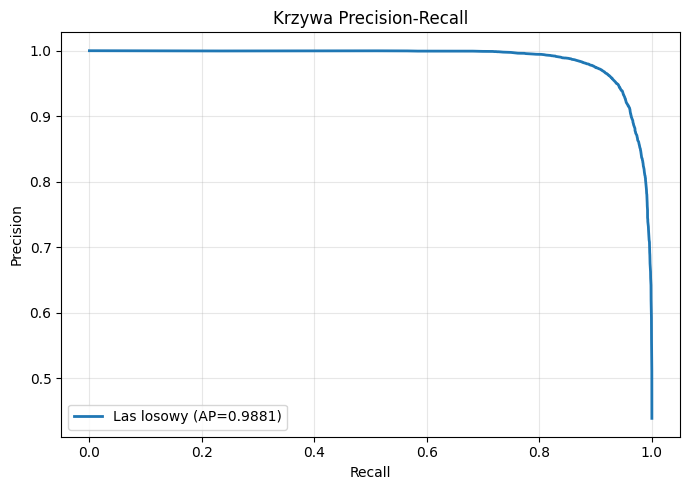

In [22]:
plot_pr_curve(best_model_rf, X_test, y_test, label="Las losowy")

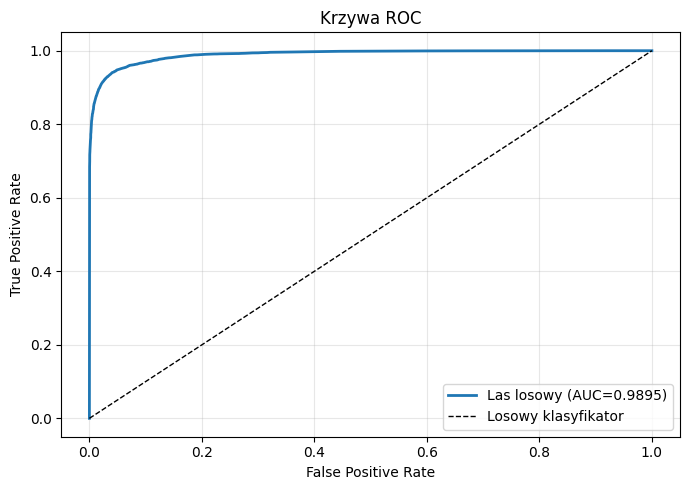

In [23]:
plot_roc_curve(best_model_rf, X_test, y_test, label="Las losowy")

### 3.3 XGBoost

In [24]:
search = tune_hyperparameters(preprocessor, X_train, y_train, cv=3)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Najlepsze parametry:
  model__learning_rate: 0.1
  model__max_depth: 7
  model__n_estimators: 100

Najlepsze F1 (CV): 0.9476


In [25]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train, cv=3)

print("Walidacja krzyżowa najlepszego modelu (3-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (3-fold):
 accuracy       f1  roc_auc
 0.951410 0.943515 0.990254
 0.952295 0.944152 0.991066
 0.951695 0.943489 0.991498

Średnie:
accuracy    0.9518
f1          0.9437
roc_auc     0.9909

Odchylenia standardowe:
accuracy    0.0005
f1          0.0004
roc_auc     0.0006


In [26]:
best_model_xgb = search.best_estimator_
metrics_xgb = evaluate(best_model_xgb, X_test, y_test)

accuracy    0.9573
f1          0.9509
roc_auc     0.9929

              precision    recall  f1-score   support

dissatisfied       0.95      0.97      0.96     14528
   satisfied       0.96      0.94      0.95     11365

    accuracy                           0.96     25893
   macro avg       0.96      0.96      0.96     25893
weighted avg       0.96      0.96      0.96     25893



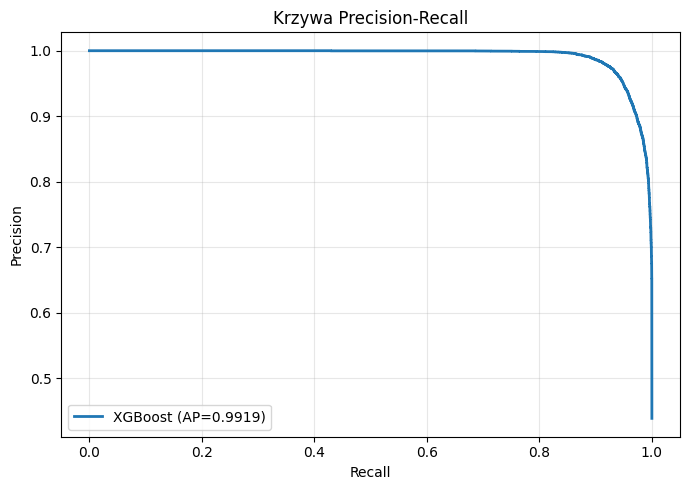

In [27]:
plot_pr_curve(best_model_xgb, X_test, y_test, label="XGBoost")

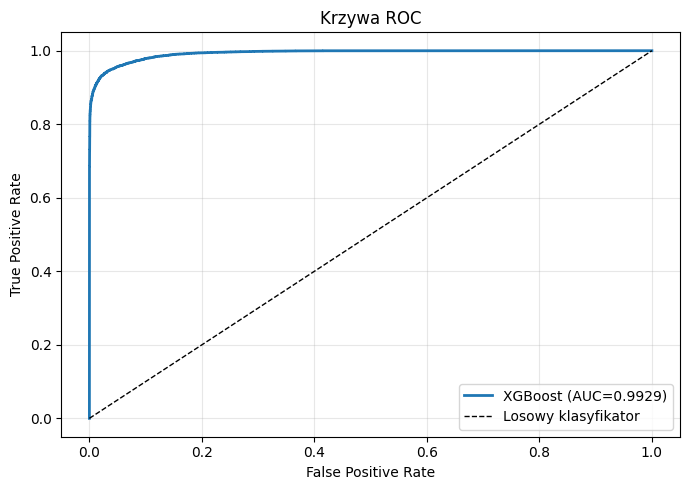

In [28]:
plot_roc_curve(best_model_xgb, X_test, y_test, label="XGBoost")

### 3.4 Porównanie modeli

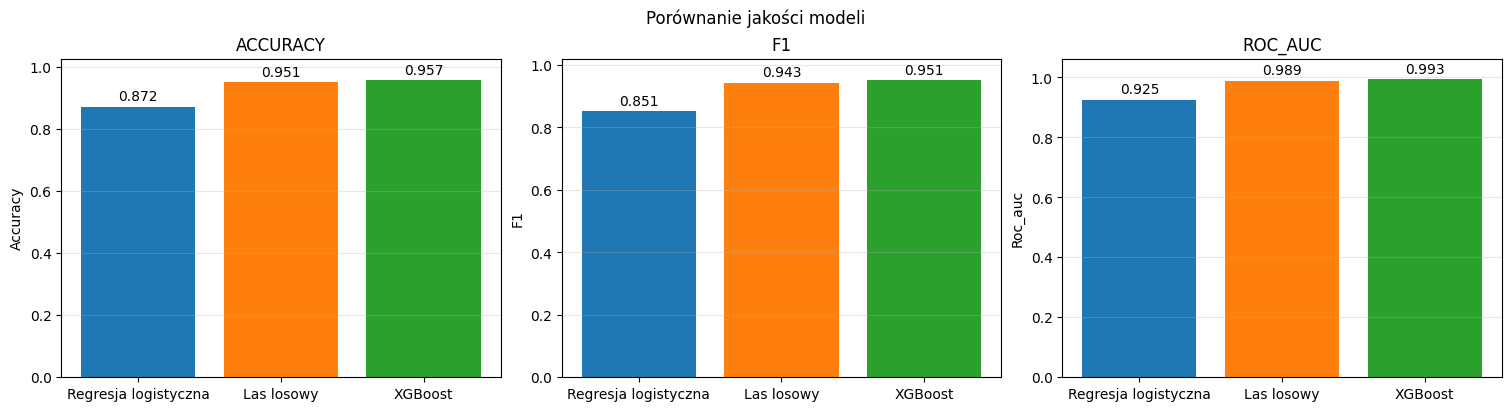

In [29]:
metrics_dict = {
    "Regresja logistyczna": metrics_lr,
    "Las losowy": metrics_rf,
    "XGBoost": metrics_xgb,
}

plot_model_metric_comparison(metrics_dict)

- Regresja Logistyczna odstaje od pozostałych modeli, osiągając najniższe wyniki we wszystkich trzech metrykach.
- Modele oparte na drzewach decyzyjnych (Random Forest i XGBoost) radzą sobie znacznie lepiej i osiągają bardzo wysokie, zbliżone do siebie rezultaty (ponad 0,95 dla Accuracy i F1 oraz niemal 1,0 dla ROC AUC).
- XGBoost okazuje się najlepszym modelem we wszystkich trzech kategoriach, choć jego przewaga nad modelem Random Forest jest marginalna.

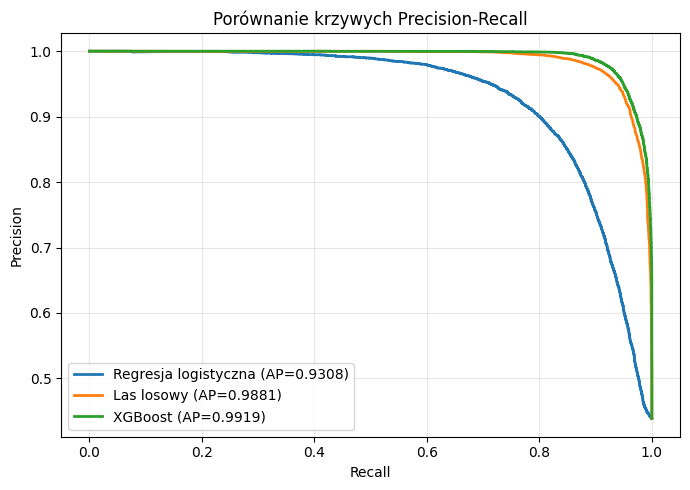

In [30]:
models = [best_model_lr, best_model_rf, best_model_xgb]
labels = ["Regresja logistyczna", "Las losowy", "XGBoost"]

plot_pr_curves(models, X_test, y_test, labels)

- Zarówno XGBoost, jak i Random Forest radzą sobie doskonale. Utrzymują niemal idealną precyzję (blisko 1,0) aż do momentu, gdy czułość przekracza poziom 0,9.
- XGBoost jest nieznacznie lepszy, co widać po tym, że jego krzywa znajduje się minimalnie wyżej w fazie spadku. Potwierdza to również najwyższa wartość pola pod krzywą.
- Model regresji logistycznej wyraźnie odstaje od pozostałych. Jego precyzja zaczyna stopniowo i zauważalnie spadać już przy czułości na poziomie około 0,6, co przekłada się na najniższy ogólny wynik AP.

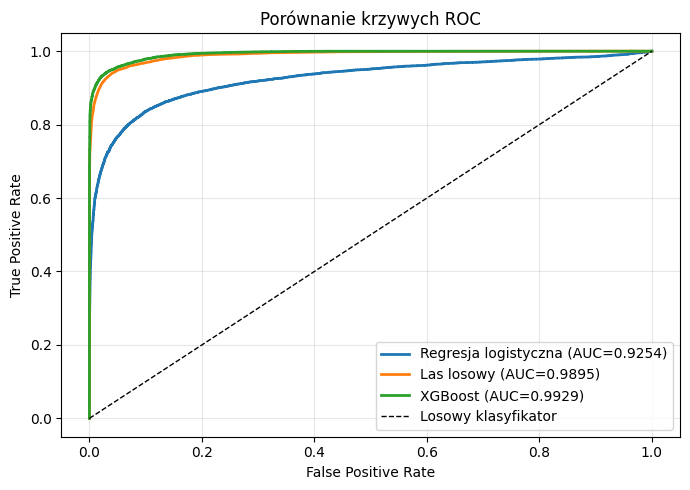

In [31]:
plot_roc_curves(models, X_test, y_test, labels)

- Zarówno XGBoost, jak i Random Forest osiągają wyniki bliskie ideałowi (1,0). Ich krzywe błyskawicznie pną się w stronę lewego górnego rogu, co oznacza, że modele te potrafią bezbłędnie zidentyfikować większość pozytywnych przypadków (True Positive Rate) przy niemal zerowym udziale błędnych alarmów (False Positive Rate).
- Wskaźnik AUC dla krzywej ROC ostatecznie pieczętuje pozycję XGBoost jako najlepszego modelu w tym zestawieniu, zachowując minimalną przewagę nad Lasem Losowym.
- Mimo że Regresja Logistyczna wyraźnie ustępuje rywalom, jej wynik (AUC = 0,9255) wciąż jest bardzo wysoki. Pokazuje to, że w danych tkwi silny i wyraźny sygnał predykcyjny, dzięki czemu nawet prostszy model liniowy radzi sobie wielokrotnie lepiej niż klasyfikator losowy.

### 3.5 Wnioski z Eksperymentu 1

In [32]:
results_exp1 = (
    pd.DataFrame(
        {"Regresja logistyczna": metrics_lr, "Las losowy": metrics_rf, "XGBoost": metrics_xgb}
    )
    .T.rename(columns={"accuracy": "Accuracy", "f1": "F1", "roc_auc": "ROC AUC"})
)
results_exp1.index.name = "Model"
results_exp1.round(4).style.highlight_max(axis=0, props="font-weight: bold; color: green")

,Accuracy,F1,ROC AUC
Model,,,
Regresja logistyczna,0.872100,0.851400,0.925400
Las losowy,0.950800,0.943500,0.989500
XGBoost,0.957300,0.950900,0.992900


Zgodnie z postawioną hipotezą, modele zespołowe (Las Losowy oraz XGBoost) wyraźnie przewyższają Regresję Logistyczną pod względem jakości predykcji. Różnica ta jest szczególnie widoczna w przypadku metryki F1, gdzie modele zespołowe wykazują poprawę o ~10 punktów procentowych.

XGBoost oraz Las Losowy osiągają bardzo zbliżone, znakomite wyniki (F1 ~0,96, ROC AUC na poziomie ~0,995). Ich przewagę doskonale obrazuje również krzywa Precision-Recall, gdzie przebieg dla obu modeli zespołowych jest niemal identyczny i utrzymuje się bardzo blisko wartości maksymalnych (Average Precision na poziomie ~0,99). Wskazuje to na wysoką zdolność obu tych podejść do skutecznego uchwycenia złożonych, nieliniowych zależności w analizowanym zbiorze danych. XGBoost okazał się nieznacznie, marginalnie lepszy we wszystkich metrykach.

Regresja logistyczna, mimo zauważalnie niższych wyników na każdym z wykresów, nadal stanowi solidny i użyteczny punkt odniesienia (tzw. baseline). Jej dodatkową zaletą w tym kontekście jest przejrzystość – dostarcza ona wysoce interpretowalnych wag poszczególnych cech, czego brakuje "czarnym skrzynkom", jakimi bywają zaawansowane modele zespołowe.

## 4. Eksperyment 2 — Efektywność próbkowania z wykorzystaniem TabPFN

**Pytanie badawcze:** Czy pretrenowany model oparty na architekturze Transformer (TabPFN) potrafi osiągnąć lepsze wyniki generalizacji na bardzo małym zbiorze treningowym w porównaniu do klasycznych metod uczenia maszynowego?

**Hipoteza:** Przy mocno ograniczonej liczbie próbek treningowych TabPFN osiągnie wyższą skuteczność niż XGBoost i Las Losowy trenowane na tych samych danych.

Eksperyment porównuje trzy modele trenowane na losowych podzbiorach treningowych o rozmiarach [100, 250, 500] i ewaluowane na pełnym zbiorze testowym. Modele klasyczne używają najlepszych hiperparametrów znalezionych w Eksperymencie 1. W odróżnieniu od Eksperymentu 1, walidacja krzyżowa nie jest stosowana — celem jest ocena jakości przy dokładnie N próbkach treningowych, a nie szacowanie wariancji modelu.

In [33]:
import subprocess, sys, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

In [34]:
script = "src/scripts/run_tabpfn_experiment.py"
with subprocess.Popen(
    [sys.executable, "-u", str(script)],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    cwd="..",
) as proc:
    for line in iter(proc.stdout.readline, ""):
        print(line, end="", flush=True)
    proc.wait()
    if proc.returncode != 0:
        print(f"\nBłąd: skrypt zakończył się kodem {proc.returncode}")

Ładowanie i przygotowanie danych...
X_train: (103594, 24) → 29 cech po OHE
X_test:  (25893, 24)

--- sample_size = 100 ---
  TabPFN:  f1=0.8792  roc_auc=0.9576
  XGBoost: f1=0.8323  roc_auc=0.9201
  RF:      f1=0.8478  roc_auc=0.9434
--- sample_size = 250 ---
/usr/local/lib/python3.12/dist-packages/tabpfn/validation.py:139: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
  TabPFN:  f1=0.9139  roc_auc=0.9817
  XGBoost: f1=0.8898  roc_auc=0.9642
  RF:      f1=0.8747  roc_auc=0.9618
--- sample_size = 500 ---
/usr/local/lib/python3.12/dist-packages/tabpfn/validation.py:139: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
  TabPFN:  f1=0.9211  roc_auc=0.9842
  XGBoost: f1=0.9094  roc_auc=0.9737
  RF:      f1=0

In [35]:
results_df = pd.read_csv("../data/tabpfn_experiment_results.csv").set_index(["model", "sample_size"])
print(results_df.round(4).to_string())

                     accuracy      f1  roc_auc
model   sample_size                           
TabPFN  100            0.8919  0.8792   0.9576
XGBoost 100            0.8519  0.8323   0.9201
RF      100            0.8678  0.8478   0.9434
TabPFN  250            0.9257  0.9139   0.9817
XGBoost 250            0.9021  0.8898   0.9642
RF      250            0.8940  0.8747   0.9618
TabPFN  500            0.9326  0.9211   0.9842
XGBoost 500            0.9214  0.9094   0.9737
RF      500            0.9166  0.9023   0.9705


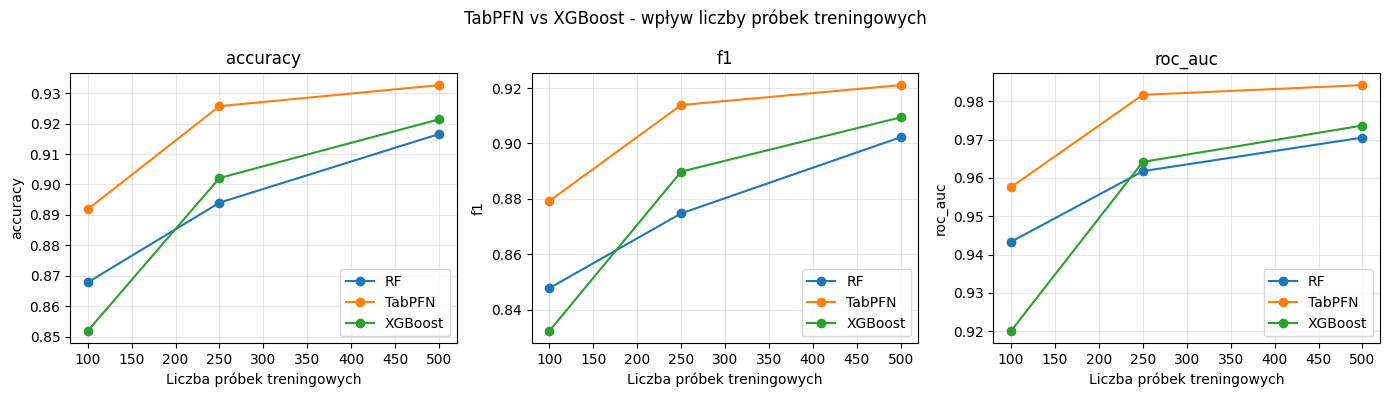

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ["accuracy", "f1", "roc_auc"]):
    for model_name, group in results_df.reset_index().groupby("model"):
        ax.plot(group["sample_size"], group[metric], marker="o", label=model_name)
    ax.set_title(metric)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("TabPFN vs XGBoost - wpływ liczby próbek treningowych")
plt.tight_layout()
plt.show()

### 4.1 Wnioski z Eksperymentu 2

Zgodnie z postawioną hipotezą, model TabPFN systematycznie przewyższa algorytmy XGBoost i Las Losowy (RF) we wszystkich badanych metrykach (Accuracy, F1, ROC AUC) i przy każdym testowanym rozmiarze zbioru. Wyniki te jednoznacznie demonstrują wyższą efektywność próbkowania.

Analiza krzywych uczenia ukazuje, że różnica w skuteczności między TabPFN a modelami klasycznymi maleje w miarę zwiększania rozmiaru próbki treningowej (od 100 do 500). Modele zespołowe, w szczególności XGBoost, notują bardzo szybki przyrost jakości, co wskazuje, że początkowa ogromna korzyść płynąca z pretrainingu zmniejsza się, gdy tradycyjne algorytmy otrzymują więcej danych do samodzielnego znalezienia wzorców.

Eksperyment potwierdza ogromną przydatność modeli opartych na architekturze Transformer (takich jak TabPFN) w sytuacjach skrajnego niedoboru danych. Potrafią one zapewnić wysoką jakość generalizacji już przy 100 próbkach treningowych, podczas gdy klasyczne modele zespołowe przy tak małym wolumenie danych radzą sobie zauważalnie gorzej.

## 5. Eksperyment 3 — Analiza ważności cech i selekcja

**Pytanie badawcze:** Które z cech lotu i pasażera są najsilniejszymi predykatorami zadowolenia i w jakim stopniu różne metody selekcji cech (SelectKBest, RFE) są ze sobą zgodne w ich identyfikacji?

**Hipoteza:** Oceny usług pokładowych będą dominującymi predyktorami. Rankingi cech uzyskane różnymi metodami będą spójne, a ich selekcja pozwoli uprościć model regresji logistycznej bez pogorszenia jego skuteczności.

### 5.1 SelectKBest

Metoda filtracyjna; wybiera `k` najlepszych cech na podstawie testu statystycznego. Porównano dwie funkcje oceny: `f_classif` (test ANOVA, zależności liniowe) i `mutual_info_classif` (wzajemna informacja, zależności nieliniowe).

In [37]:
results = run_selectkbest_experiment(
    preprocessor, X_train, y_train, X_test, y_test,
    k_values=[5, 10, 15, 20, 25, "all"],
    score_funcs=[f_classif, mutual_info_classif]
)


── f_classif ──


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


  k=   5  accuracy=0.8415  f1=0.8160  roc_auc=0.9034


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


  k=  10  accuracy=0.8461  f1=0.8216  roc_auc=0.9071


...

  k=  20  accuracy=0.8655  f1=0.8430  roc_auc=0.9203


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


  k=  25  accuracy=0.8693  f1=0.8475  roc_auc=0.9222


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


  k= all  accuracy=0.8701  f1=0.8481  roc_auc=0.9236


In [38]:
print(results.to_string(index=False))

         score_func   k  accuracy       f1  roc_auc
          f_classif   5  0.841540 0.815968 0.903428
          f_classif  10  0.846097 0.821565 0.907106
          f_classif  15  0.851388 0.827056 0.910291
          f_classif  20  0.867416 0.845186 0.920995
          f_classif  25  0.868690 0.846709 0.921958
          f_classif all  0.870081 0.848140 0.923574
mutual_info_classif   5  0.842931 0.817974 0.903879
mutual_info_classif  10  0.846793 0.822402 0.907552
mutual_info_classif  15  0.854130 0.830346 0.911931
mutual_info_classif  20  0.865485 0.842960 0.920285
mutual_info_classif  25  0.869308 0.847458 0.922192
mutual_info_classif all  0.870081 0.848140 0.923574


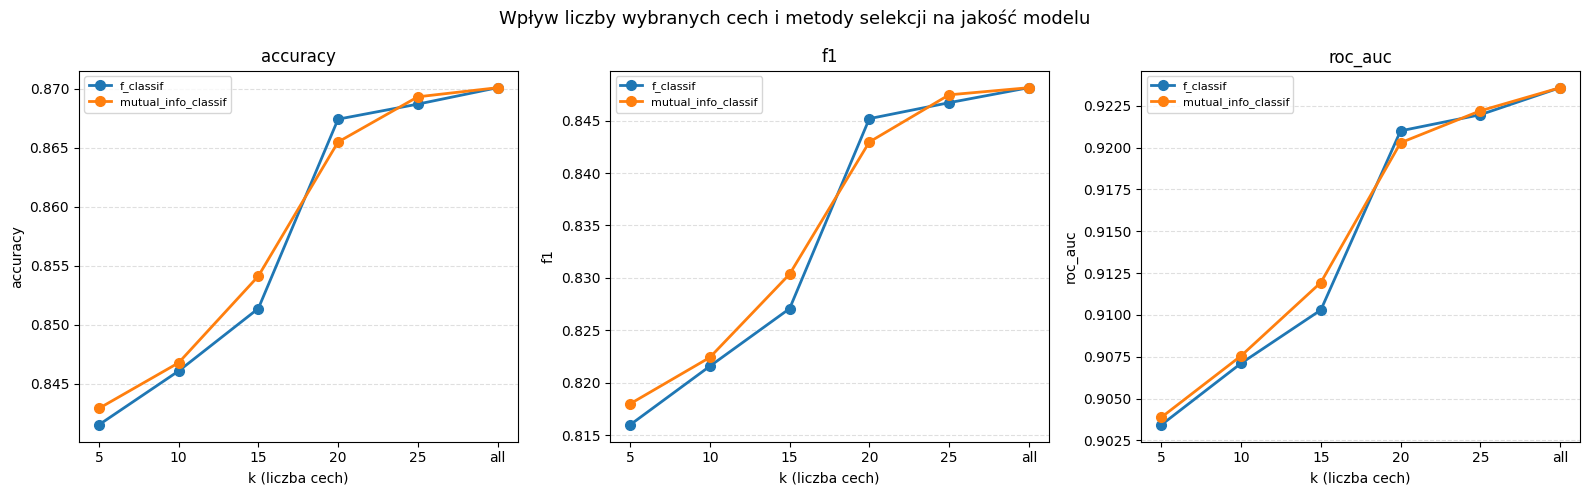

In [39]:
plot_k_vs_metrics(results)

In [40]:
scores_f = get_feature_scores(preprocessor, X_train, y_train, f_classif)
scores_f

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


,feature,score_func,score,p_value,rank
0,num__avg_service_score,f_classif,3763.991008,0.000000e+00,1
1,num__Online boarding,f_classif,3703.801599,0.000000e+00,2
2,cat__Class_Business,f_classif,3609.557647,0.000000e+00,3
3,cat__Class_Eco,f_classif,2821.855750,0.000000e+00,4
4,cat__Type of Travel_Personal Travel,f_classif,2616.532274,0.000000e+00,5
5,cat__Type of Travel_Business travel,f_classif,2616.532274,0.000000e+00,6
6,num__Inflight entertainment,f_classif,1989.325107,0.000000e+00,7
7,num__Seat comfort,f_classif,1426.259306,6.867523e-292,8
8,num__On-board service,f_classif,1168.049268,3.219368e-242,9
9,num__Cleanliness,f_classif,1070.336852,4.044274e-223,10


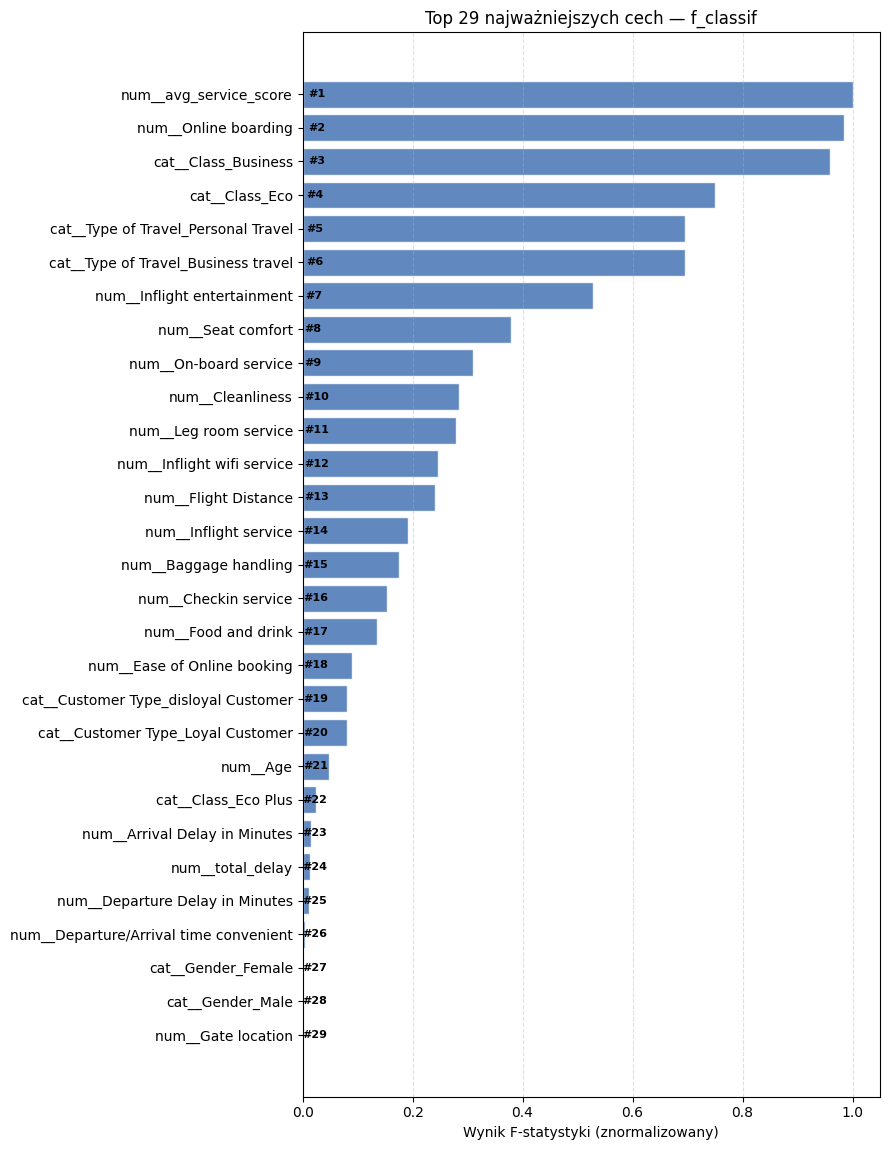

In [41]:
plot_feature_scores(scores_f,  top_n=29)

In [42]:
scores_mi = get_feature_scores(preprocessor, X_train, y_train, mutual_info_classif)
scores_mi

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


,feature,score_func,score,p_value,rank
0,num__Online boarding,mutual_info_classif,0.226939,NaN,1
1,num__Inflight wifi service,mutual_info_classif,0.159112,NaN,2
2,num__avg_service_score,mutual_info_classif,0.159087,NaN,3
3,cat__Class_Business,mutual_info_classif,0.144600,NaN,4
4,cat__Type of Travel_Business travel,mutual_info_classif,0.122149,NaN,5
5,cat__Class_Eco,mutual_info_classif,0.122143,NaN,6
6,cat__Type of Travel_Personal Travel,mutual_info_classif,0.113102,NaN,7
7,num__Inflight entertainment,mutual_info_classif,0.101703,NaN,8
8,num__Seat comfort,mutual_info_classif,0.082869,NaN,9
9,num__Leg room service,mutual_info_classif,0.062837,NaN,10


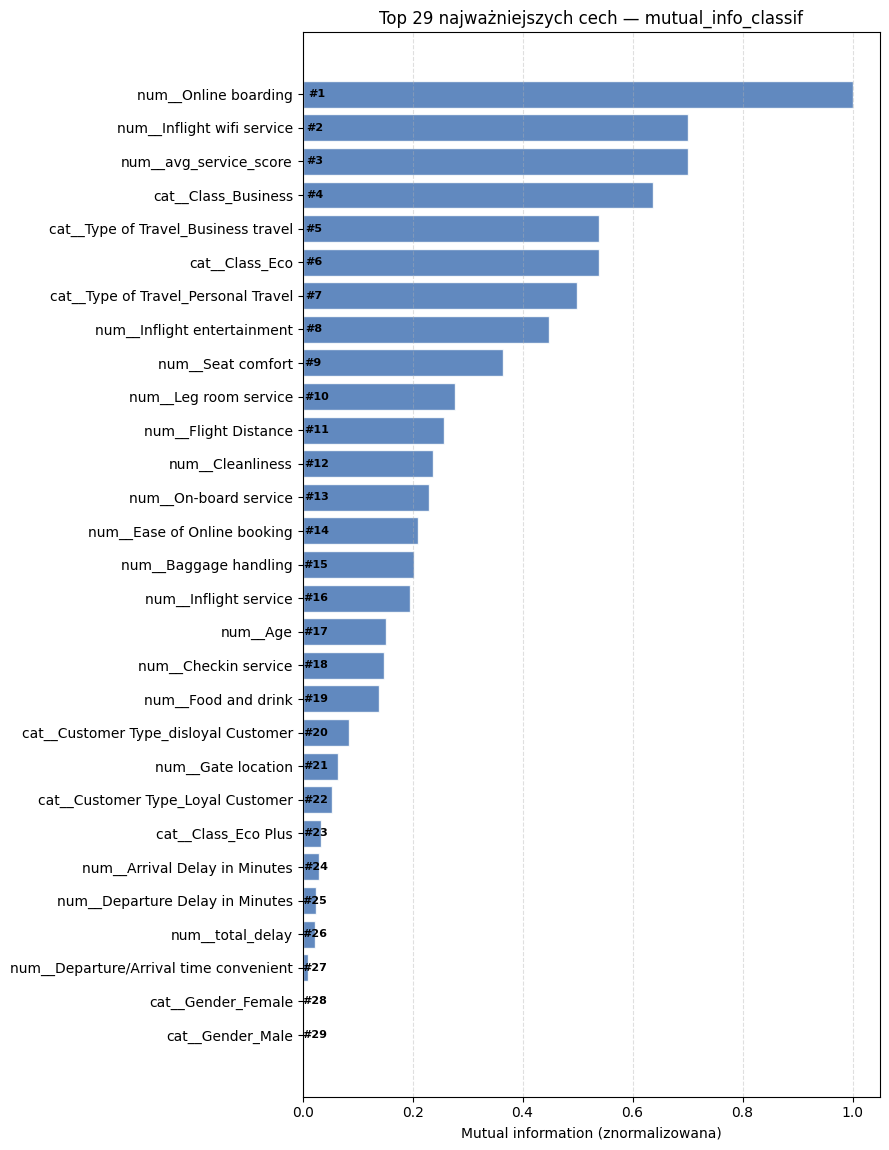

In [43]:
plot_feature_scores(scores_mi, top_n=29)

### 5.2 Wnioski z SelectKBest

Zgodnie z postawioną hipotezą, usługi bezpośrednio wpływające na komfort pasażera są najsilniejszymi predyktorami. Obie metody jednoznacznie wskazują w ścisłej czołówce takie cechy jak: `avg_service_score` oraz `Online boarding`.

Mimo ogólnej spójności, warto zauważyć, że występują wyraźne różnice w istotności poszczególnych cech pomiędzy zastosowanymi podejściami. Najlepszym tego przykładem jest `Inflight wifi service`, który dla `mutual_info_classif` okazał się kluczowy i zajął drugie miejsce, podczas gdy dla `f_classif` spadł dopiero na trzynastą pozycję. Ponadto metody różnią się samym liderem rankingu.

Obie metody wykazują niemal pełną jednomyślność przy identyfikacji "ogona" zestawienia. Wynika z nich, że opóźnienia lotów (zarówno odlotu, jak i przylotu), płeć pasażera oraz lokalizacja bramki mają marginalny wpływ na końcowe zadowolenie z podróży i mogą być pominięte w procesie modelowania.

Wykresy liniowe obrazujące metryki (Accuracy, F1, ROC AUC) pokazują stromy wzrost jakości predykcji do poziomu 20 wyselekcjonowanych cech. Maksymalne wyniki model osiąga przy około 25 cechach, po czym krzywe się wypłaszczają. Potwierdza to przypuszczenie, że model można bezpiecznie uprościć (odrzucając kilka najsłabszych cech) bez utraty skuteczności, jednak zbyt agresywna selekcja (np. ograniczenie się do 10–15 cech) skutkuje już wyraźnym spadkiem jakości predykcji. Wybór konkretnej metody selekcji (`f_classif` vs `mutual_info_classif`) ma w tym przypadku znikomy wpływ na ostateczne wyniki modelu.

### 5.3 RFE (Recursive Feature Elimination)

Metoda iteracyjnie eliminuje najmniej istotne cechy na podstawie wag modelu. Porównano dwa estymatory bazowe: Regresję Logistyczną i Las Losowy.

In [44]:
# Fast mode: zmniejszamy liczbę drzew RF używanych w RFE
from sklearn.ensemble import RandomForestClassifier as _RFC
from sklearn.linear_model import LogisticRegression as _LR

_fast_rfe_estimators = {
    "LR": _LR(C=0.01, l1_ratio=1.0, solver="saga", max_iter=5000, random_state=42),
    "RF": _RFC(n_estimators=20, random_state=42, n_jobs=1),
}

In [45]:
results_rfe = run_rfe_experiment(
    preprocessor, X_train, y_train, X_test, y_test,
    estimators=_fast_rfe_estimators,
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

estimator=LR n_features=5 accuracy=0.8446 f1=0.8195 roc_auc=0.9049


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

estimator=LR n_features=10 accuracy=0.8609 f1=0.8376 roc_auc=0.9189


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

...

estimator=RF n_features=20 accuracy=0.8667 f1=0.8444 roc_auc=0.9212


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


estimator=RF n_features=25 accuracy=0.8701 f1=0.8483 roc_auc=0.9235


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


estimator=RF n_features=all accuracy=0.8701 f1=0.8481 roc_auc=0.9236


In [46]:
print(results_rfe.to_string(index=False))

estimator n_features  accuracy       f1  roc_auc
       LR          5  0.844591 0.819535 0.904856
       LR         10  0.860850 0.837564 0.918868
       LR         15  0.869810 0.848187 0.923605
       LR         20  0.869115 0.847156 0.923590
       LR         25  0.869231 0.847285 0.923592
       LR        all  0.870081 0.848140 0.923574
       RF          5  0.844862 0.820148 0.900299
       RF         10  0.851273 0.827734 0.908376
       RF         15  0.860812 0.838095 0.916701
       RF         20  0.866682 0.844448 0.921189
       RF         25  0.870081 0.848263 0.923477
       RF        all  0.870081 0.848140 0.923574


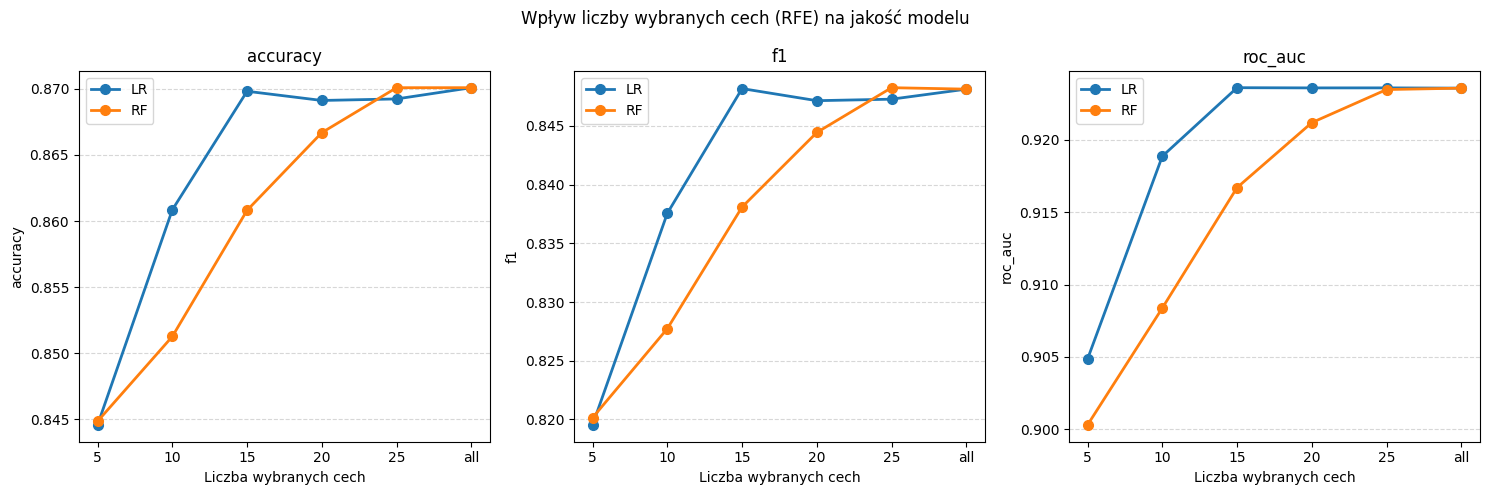

In [47]:
plot_n_features_vs_metrics(results_rfe)

In [48]:
rankings_lr = get_feature_rankings(
    preprocessor, X_train, y_train,
    estimator_name="LR",
    estimators=_fast_rfe_estimators,
)
rankings_lr

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

,feature,ranking
0,cat__Type of Travel_Business travel,1
1,num__avg_service_score,2
2,cat__Type of Travel_Personal Travel,3
3,cat__Customer Type_disloyal Customer,4
4,cat__Class_Business,5
5,num__Online boarding,6
6,cat__Customer Type_Loyal Customer,7
7,cat__Class_Eco,8
8,num__Departure/Arrival time convenient,9
9,num__On-board service,10


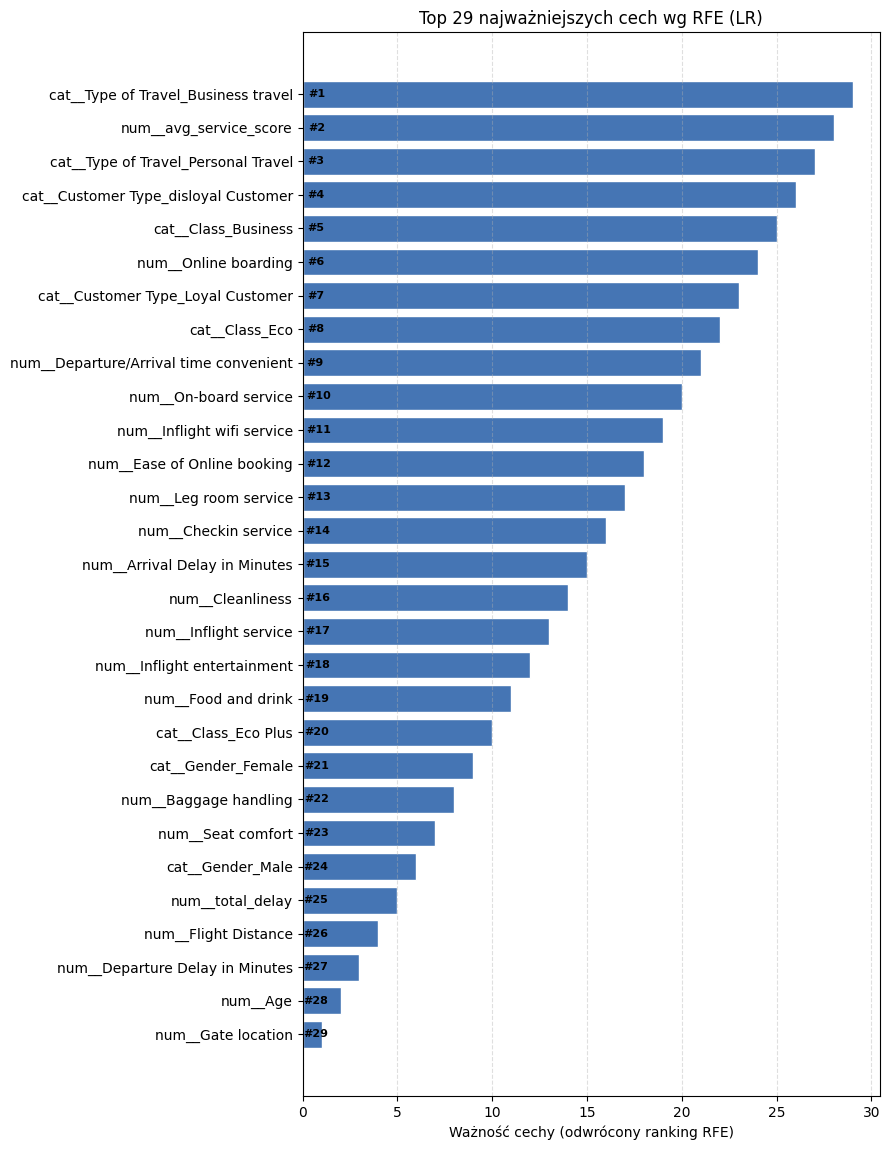

In [49]:
plot_feature_rankings(rankings_lr, estimator_name="LR", top_n=29)

In [50]:
rankings_rf = get_feature_rankings(
    preprocessor, X_train, y_train,
    estimator_name="RF",
    estimators=_fast_rfe_estimators,
)
rankings_rf

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


,feature,ranking
0,num__Flight Distance,1
1,num__Online boarding,2
2,num__avg_service_score,3
3,num__Inflight wifi service,4
4,cat__Type of Travel_Personal Travel,5
5,cat__Class_Business,6
6,num__Age,7
7,num__Inflight entertainment,8
8,num__Ease of Online booking,9
9,cat__Class_Eco,10


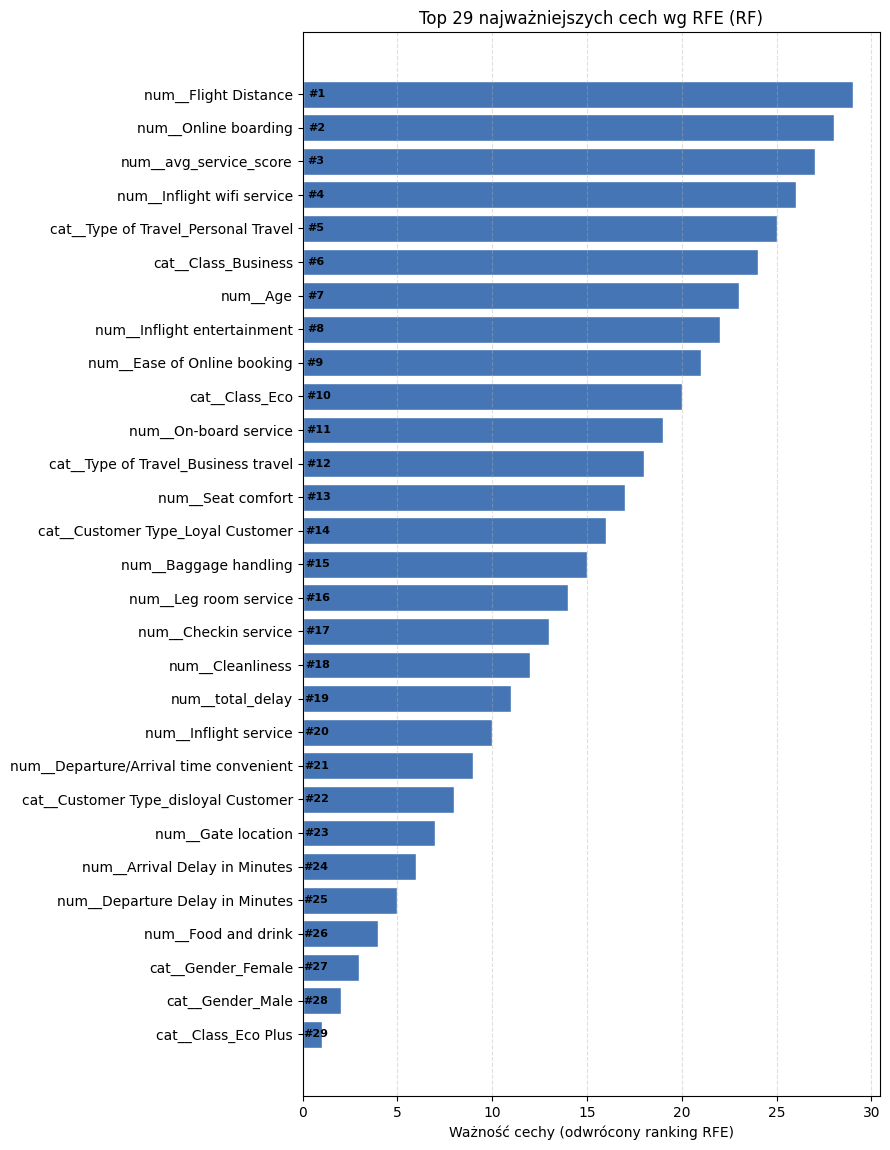

In [51]:
plot_feature_rankings(rankings_rf, estimator_name="RF", top_n=29)

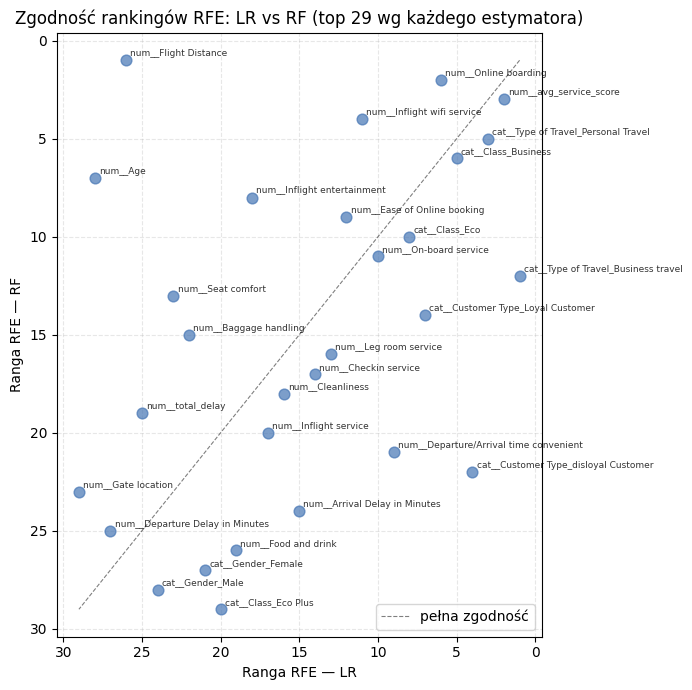

In [52]:
plot_feature_rankings_comparison(rankings_lr, rankings_rf, top_n=29)

### 5.4 Wnioski z RFE

Rankingi istotności uzyskane metodą RFE dla regresji logistycznej (LR) i lasu losowego (RF) wykazują wyraźne różnice. RFE dla regresji logistycznej nie wskazuje na `avg_service_score` jako na absolutnie kluczową cechę (plasuje ją na #4 miejscu), skupiając się w pierwszej kolejności na cechach kategorycznych związanych z profilem podróży i klienta. Z kolei RFE dla lasu losowego umieszcza `avg_service_score` (#5 miejsce), a na samego lidera wysuwa `Online boarding` oraz inne cechy związane z jakością lotu, takie jak `Flight distance` oraz `Inflight wifi service`.

Najbardziej jaskrawym dowodem na odmienną specyfikę obu modeli w procesie RFE jest cecha `Flight distance`. Dla lasu losowego jest to kluczowa zmienna (pozycja #2), podczas gdy dla regresji logistycznej stanowi ona całkowicie nieprzydatny szum informacyjny, przez co wylądowała na ostatnim (#29) miejscu.

Selekcja ~20–25 cech za pomocą RFE pozwala zachować pełną jakość bazowego modelu regresji logistycznej, co potwierdza założenia Eksperymentu 3.

Na wykresach metryk widać, że regresja logistyczna radzi sobie znacznie lepiej przy skrajnym ograniczeniu liczby cech (od 5 do 15) niż las losowy. RF przy zaledwie 5 cechach notuje drastyczny spadek efektywności (F1 spada w okolice 0,79), podczas gdy LR zachowuje stabilność (F1 ~0,82). Wynika to z faktu, że RFE dla LR bardzo precyzyjnie odfiltrowuje najsilniejsze predyktory stricte liniowe.

### 5.5 Podsumowanie Eksperymentu 3

Wszystkie przeprowadzone analizy zgodnie potwierdziły, że oceny komponentów obsługi pasażera dominują nad metrykami czysto technicznymi.

RFE dla lasu losowego wykazuje znacznie większą zgodność z wynikami SelectKBest (a w szczególności z metodą `mutual_info_classif`) niż RFE dla regresji logistycznej. Wynika to z naturalnej, zbieżnej zdolności lasu losowego i miary informacji wzajemnej do wychwytywania nieliniowych zależności oraz zaawansowanych interakcji między cechami.

Wszystkie podejścia okazały się zgodne przy wskazywaniu cech o zerowym lub marginalnym wpływie na satysfakcję. `total_delay`, `Arrival/Departure Delay`, `Gender` oraz `Gate location` niezmiennie okupują dolne paski każdego z rankingów i mogą zostać całkowicie usunięte.

Porównanie krzywych uczenia dla SelectKBest i RFE pozwala na wyciągnięcie jednoznacznego wniosku wdrożeniowego: redukcja zbioru danych do 20–25 najważniejszych cech gwarantuje zachowanie maksimum zdolności predykcyjnych modeli. Pozwala to na uproszczenie architektury systemów produkcyjnych, skrócenie czasu trenowania oraz łatwiejszą interpretację wyników bez jakiejkolwiek straty na jakości klasyfikacji.

## 6. Wnioski końcowe

| Aspekt | Wniosek |
|---|---|
| **Najlepszy model (pełne dane)** | XGBoost i Las Losowy — zbliżone wyniki (F1 ≈ 0.96, ROC AUC ≈ 0.995); XGBoost nieznacznie lepszy |
| **Hipoteza Eksperymentu 1** | ✓ Potwierdzona — XGBoost najlepszy na pełnych danych |
| **Hipoteza Eksperymentu 2** | ✓ Potwierdzona — TabPFN lepszy przy małych próbkach (100–500) |
| **Hipoteza Eksperymentu 3** | ✓ Potwierdzona — usługi pokładowe dominują; k ≈ 20 wystarczy dla regresji logistycznej |
| **Najważniejsze cechy** | `avg_service_score`, `Online boarding`, klasa podróży (`Business`/`Eco`) |
| **Zgodność SelectKBest i RFE** | Wysoka — obie metody wskazują ten sam zestaw kluczowych predyktorów |

**Rekomendacja praktyczna:**
- Do produkcji z pełnymi danymi: **XGBoost** lub **Las Losowy** (najwyższa jakość)
- Do zastosowań z deficytem danych treningowych: **TabPFN** (wyższa efektywność próbkowania)
- Do szybkiego, interpretowalnego modelu z selekcją cech: **Regresja logistyczna + SelectKBest (k=20)**

In [53]:
results_exp1.round(4).style.highlight_max(axis=0, props="font-weight: bold; color: green")

,Accuracy,F1,ROC AUC
Model,,,
Regresja logistyczna,0.872100,0.851400,0.925400
Las losowy,0.950800,0.943500,0.989500
XGBoost,0.957300,0.950900,0.992900
